# Visualising the priors and scaling relations

This notebook exposes the assumptions that AsteroScale makes by default. The first figure shows the one-dimensional priors used for unconstrained fundamental parameters. The remaining figures vary one or two stellar properties at a time to show the behaviour of the scaling relations.

These are diagnostic plots, not a synthetic stellar population or evolutionary tracks. Combinations obtained by varying one parameter while fixing the others can be mathematically useful without representing a physically self-consistent star.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from asteroscale import relations as rel
from asteroscale.solver import DEFAULT_PRIORS

plt.style.use("seaborn-v0_8-whitegrid")

## Default fundamental-parameter priors

The panels below show deterministic quantile samples from each prior. The mass prior favours lower-mass stars, the radius prior is log-uniform, and the parallax prior corresponds to the exponentially decreasing distance prior. These are broad field-star defaults; informative measurements will usually dominate them.

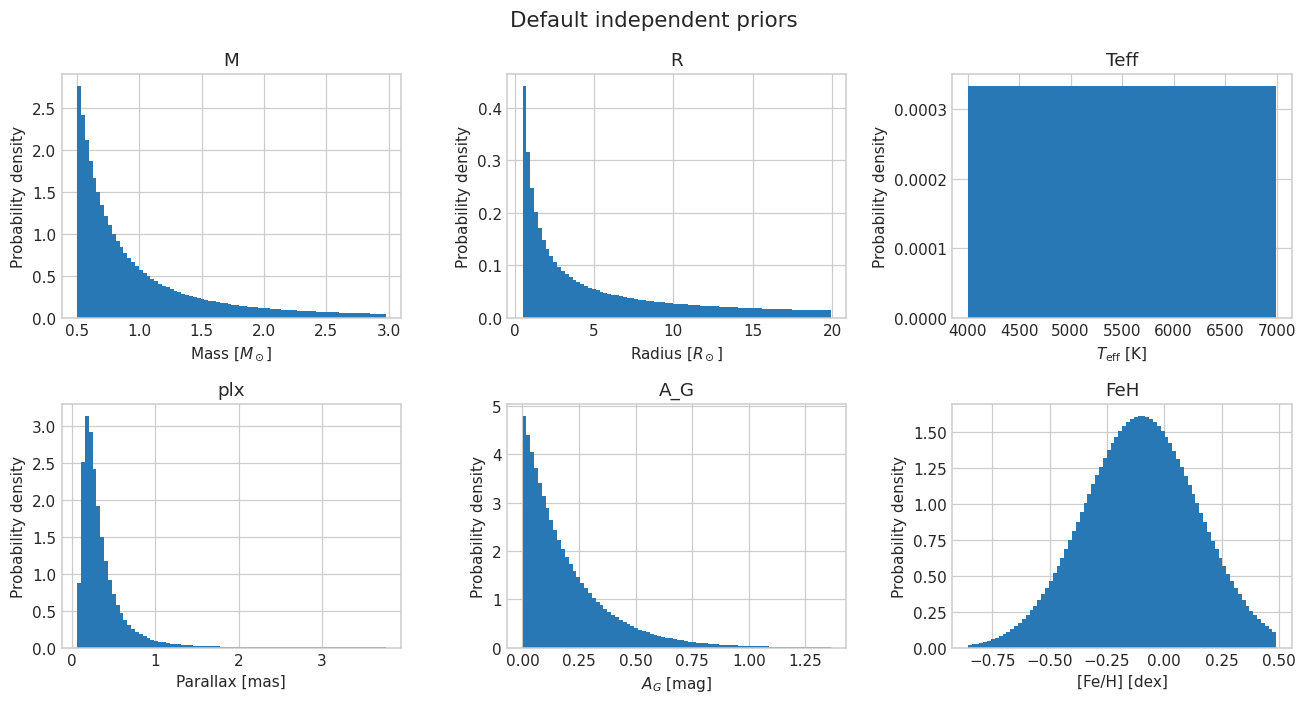

In [2]:
labels = {
    "M": r"Mass [$M_\odot$]",
    "R": r"Radius [$R_\odot$]",
    "Teff": r"$T_\mathrm{eff}$ [K]",
    "plx": "Parallax [mas]",
    "A_G": r"$A_G$ [mag]",
    "FeH": "[Fe/H] [dex]",
}
u = np.linspace(1e-4, 1 - 1e-4, 50_000)
fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))
for ax, (name, prior) in zip(axes.flat, DEFAULT_PRIORS.items()):
    values = np.asarray(prior.ppf(u))
    lo, hi = np.quantile(values, [0.001, 0.999])
    ax.hist(values, bins=80, range=(lo, hi), density=True, color="#2878b5")
    ax.set(xlabel=labels[name], ylabel="Probability density", title=name)
fig.suptitle("Default independent priors", fontsize=14)
fig.tight_layout()
plt.show()

## Seismic scaling with radius and mass

At fixed effective temperature and metallicity, both $\nu_\max$ and $\Delta\nu$ decrease rapidly as a star expands. The solar reference point is marked for the one-solar-mass curve.

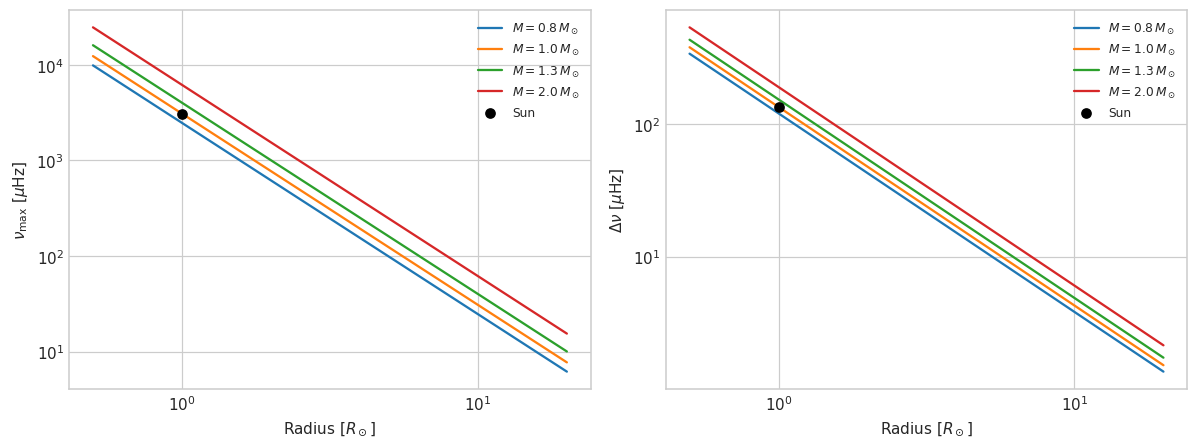

In [3]:
radius = np.geomspace(0.5, 20, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for mass in (0.8, 1.0, 1.3, 2.0):
    axes[0].loglog(radius, rel.numax(mass, radius, rel.TEFF_SUN, 0.0), label=fr"$M={mass}\,M_\odot$")
    axes[1].loglog(radius, rel.dnu(mass, radius, rel.TEFF_SUN, 0.0), label=fr"$M={mass}\,M_\odot$")
axes[0].scatter(1, rel.NUMAX_SUN, color="black", zorder=5, label="Sun")
axes[1].scatter(1, rel.DNU_SUN, color="black", zorder=5, label="Sun")
axes[0].set(xlabel=r"Radius [$R_\odot$]", ylabel=r"$\nu_\max$ [$\mu$Hz]")
axes[1].set(xlabel=r"Radius [$R_\odot$]", ylabel=r"$\Delta\nu$ [$\mu$Hz]")
for ax in axes: ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Temperature and metallicity corrections

The large-separation reference function uses the Guggenberger et al. (2016) temperature-metallicity correction and is renormalized to the adopted solar value. The $\nu_\max$ correction shown on the right is the molecular-weight term from Viani et al. (2017).

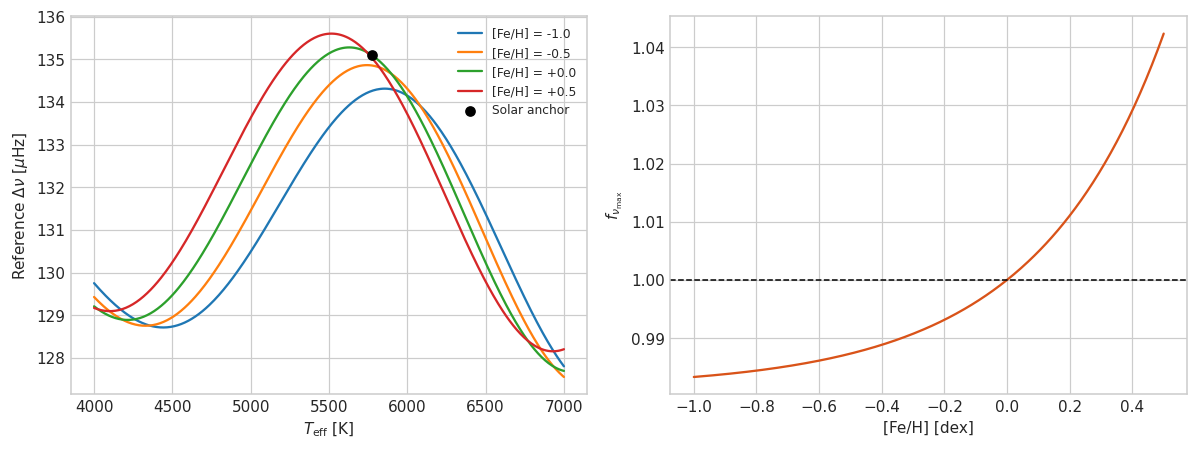

In [4]:
teff = np.linspace(4000, 7000, 400)
feh = np.linspace(-1.0, 0.5, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for metallicity in (-1.0, -0.5, 0.0, 0.5):
    axes[0].plot(teff, rel.dnu_ref(teff, metallicity), label=f"[Fe/H] = {metallicity:+.1f}")
axes[0].scatter(rel.TEFF_SUN, rel.DNU_SUN, color="black", zorder=5, label="Solar anchor")
axes[0].set(xlabel=r"$T_\mathrm{eff}$ [K]", ylabel=r"Reference $\Delta\nu$ [$\mu$Hz]")
axes[0].legend(fontsize=8)
axes[1].plot(feh, rel.f_numax(feh), color="#d95319")
axes[1].axhline(1, color="black", ls="--", lw=1)
axes[1].set(xlabel="[Fe/H] [dex]", ylabel=r"$f_{\nu_\max}$")
fig.tight_layout()
plt.show()

## Oscillation envelope and granulation

For this diagnostic sequence, mass and effective temperature are held at their solar values while radius changes. Luminosity is computed consistently from radius and temperature before evaluating the Ball et al. (2018) amplitudes. The granulation panel shows the Kallinger et al. (2014) relations directly as functions of $\nu_\max$.

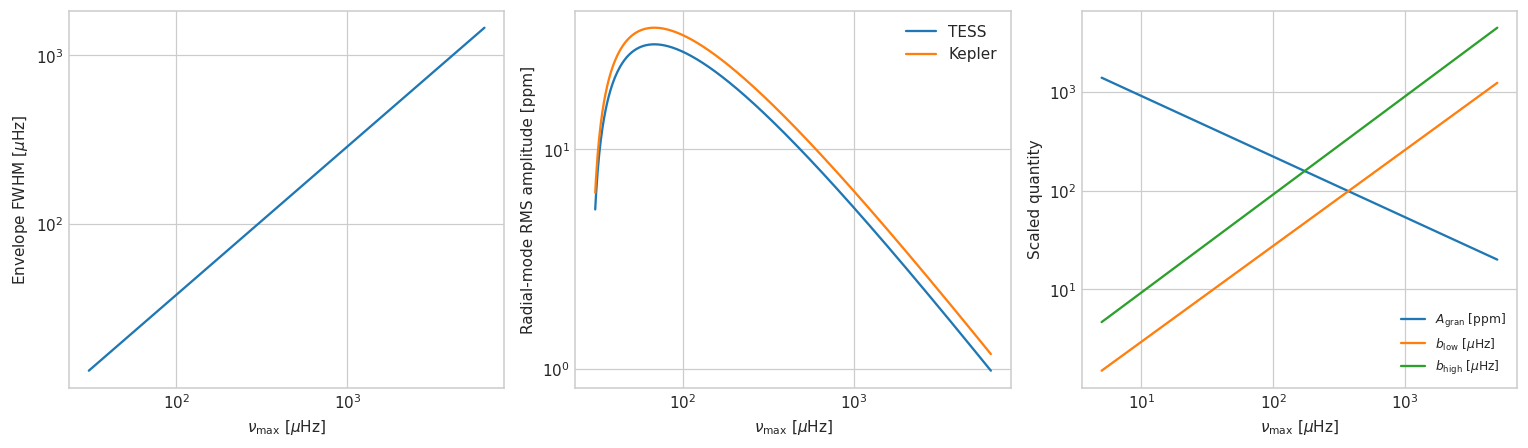

In [5]:
radius = np.geomspace(0.7, 10, 500)
mass = 1.0
teff0 = rel.TEFF_SUN
lum = rel.luminosity(radius, teff0)
nu = rel.numax(mass, radius, teff0, 0.0)
order = np.argsort(nu)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
axes[0].loglog(nu[order], rel.envelope_fwhm(nu, teff0)[order])
axes[0].set(xlabel=r"$\nu_\max$ [$\mu$Hz]", ylabel=r"Envelope FWHM [$\mu$Hz]")
for bandpass in ("TESS", "Kepler"):
    amp = rel.envelope_amplitude(mass, lum, teff0, bandpass=bandpass)
    axes[1].loglog(nu[order], amp[order], label=bandpass)
axes[1].set(xlabel=r"$\nu_\max$ [$\mu$Hz]", ylabel="Radial-mode RMS amplitude [ppm]")
axes[1].legend()
nu_grid = np.geomspace(5, 5000, 500)
axes[2].loglog(nu_grid, rel.granulation_amplitude(nu_grid, 1.0), label=r"$A_\mathrm{gran}$ [ppm]")
axes[2].loglog(nu_grid, rel.granulation_frequency_low(nu_grid), label=r"$b_\mathrm{low}$ [$\mu$Hz]")
axes[2].loglog(nu_grid, rel.granulation_frequency_high(nu_grid), label=r"$b_\mathrm{high}$ [$\mu$Hz]")
axes[2].set(xlabel=r"$\nu_\max$ [$\mu$Hz]", ylabel="Scaled quantity")
axes[2].legend(fontsize=8)
fig.tight_layout()
plt.show()

## Useful consistency checks

At the adopted solar inputs, the seismic relations should recover the package constants. The assertions below make those anchors explicit and will fail if a future change accidentally breaks them.

In [6]:
assert np.isclose(rel.numax(1.0, 1.0, rel.TEFF_SUN, 0.0), rel.NUMAX_SUN)
assert np.isclose(rel.dnu(1.0, 1.0, rel.TEFF_SUN, 0.0), rel.DNU_SUN)
assert np.isclose(rel.luminosity(1.0, rel.TEFF_SUN), 1.0)
assert np.isclose(rel.mean_density(1.0, 1.0), 1.0)
print("Solar reference checks passed.")

Solar reference checks passed.
